In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob

In [ ]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42117 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42117/status,
Dashboard: http://127.0.0.1:42117/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40245,Workers: 0
Dashboard: http://127.0.0.1:42117/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38061,Total threads: 4
Dashboard: http://127.0.0.1:41459/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:37533,


2025-10-26 18:21:21,022 - distributed.nanny - WARNING - Restarting worker


In [ ]:
#client.close()

In [9]:
path_atm = "/projects/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [17]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)

Text(0.5, 1.0, 'Total SO2 concentration (global mean)')

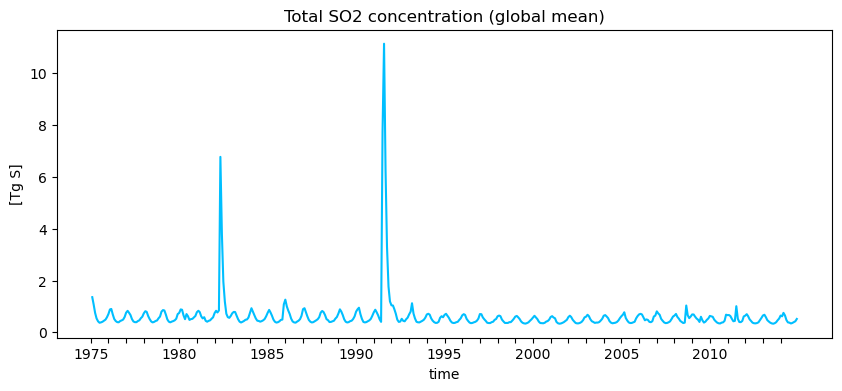

In [11]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so2_tg = so2 * K

plt.figure(figsize=(10, 4))
so2_tg.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[Tg S]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Total SO2 concentration (global mean)")

Text(0.5, 1.0, 'Stratospheric SO2 concentration (global mean)')

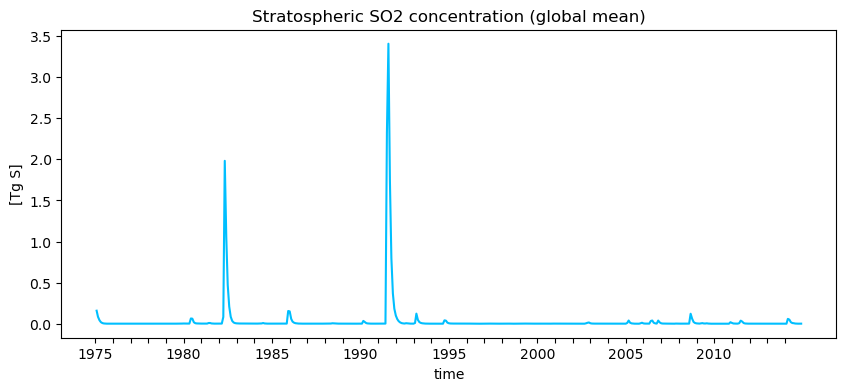

In [19]:
p_lev =100
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
C = (Ms/Mair) * M_strat_air *10**(-12)


ds_so2 = ds["SO2"]
so2_strat = ds_so2.where(ds_so2["lev"] <= p_lev)
so2_strat = so2_strat.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so2_tg_strat = so2_strat * C

plt.figure(figsize=(10, 4))
so2_tg_strat.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[Tg S]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric SO2 concentration (global mean)")

Text(0.5, 1.0, 'Total H2SO4 concentration (global mean)')

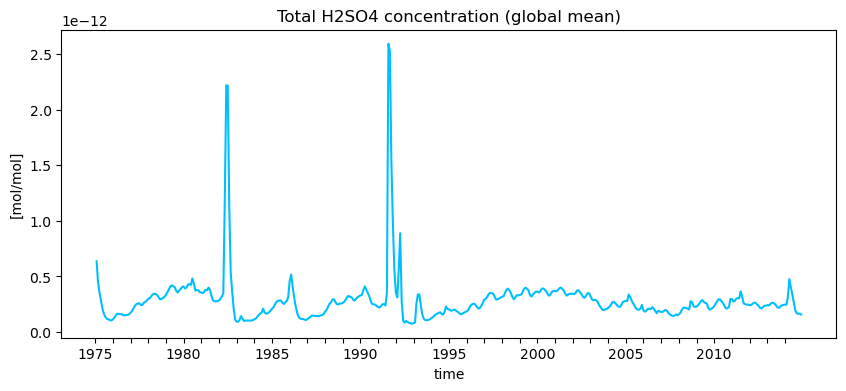

In [20]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so4 = ds["H2SO4"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[mol/mol]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Total H2SO4 concentration (global mean)")

Text(0.5, 1.0, 'Mass mixing ratio of Sulfate (global mean)')

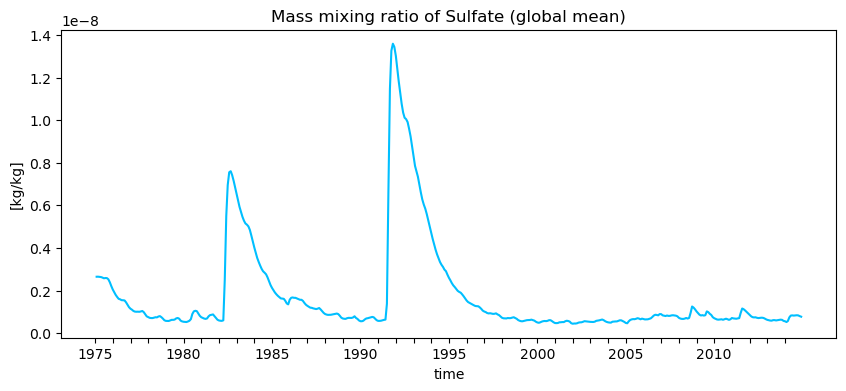

In [ ]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
mmr_so4 = ds["mmr_SULFATE"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
mmr_so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[kg/kg]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Mass mixing ratio of Sulfate (global mean)")

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (global mean)')

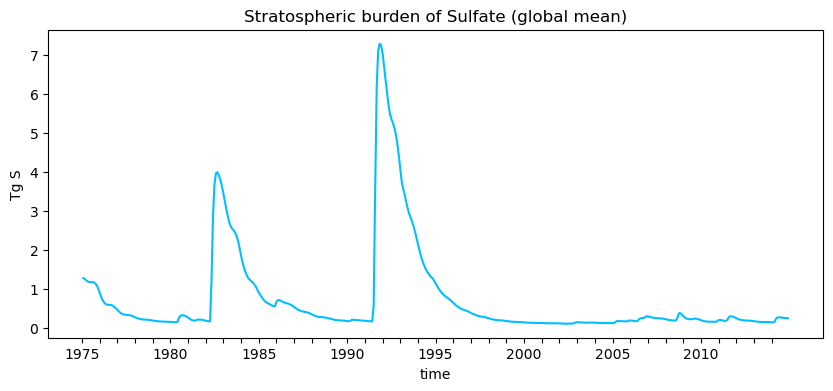

In [21]:
Mo = 15.999
Mso4 = Ms + (4 * Mo)
c = Ms/Mso4

mmr_sulf = ds["mmr_SULFATE"]
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd = so4_burd.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden = so4_burd * M_strat_air *10**(-12)
so4_burden_TgS = so4_burden * c

plt.figure(figsize=(10, 4))
so4_burden_TgS.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric burden of Sulfate (global mean)")

Text(0.5, 1.0, 'Stratospheric burden of Sulfate from Pinatubo (global mean) (-background)')

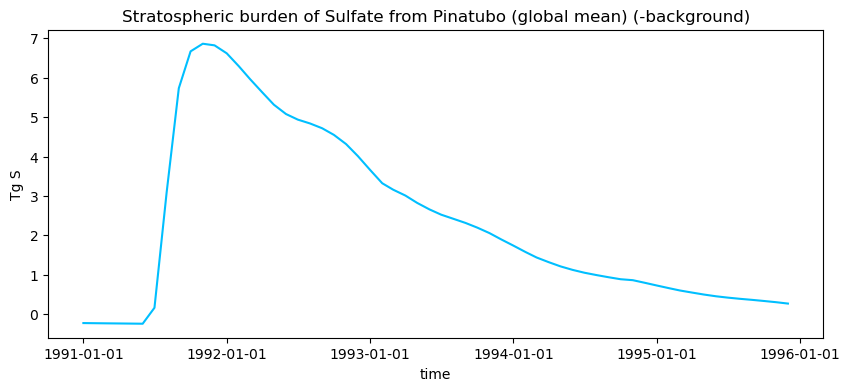

In [22]:
background = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so4_burd_Pinatubo = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1991 <= t.year <= 1995])
so4_burden_Pinatubo = so4_burd_Pinatubo - background

plt.figure(figsize=(10, 4))
so4_burden_Pinatubo.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1991, 1997) 
year_ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
plt.xticks(
    year_ticks
)
plt.ylabel("Tg S")
plt.title("Stratospheric burden of Sulfate from Pinatubo (global mean) (-background)")

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (Tropics)')

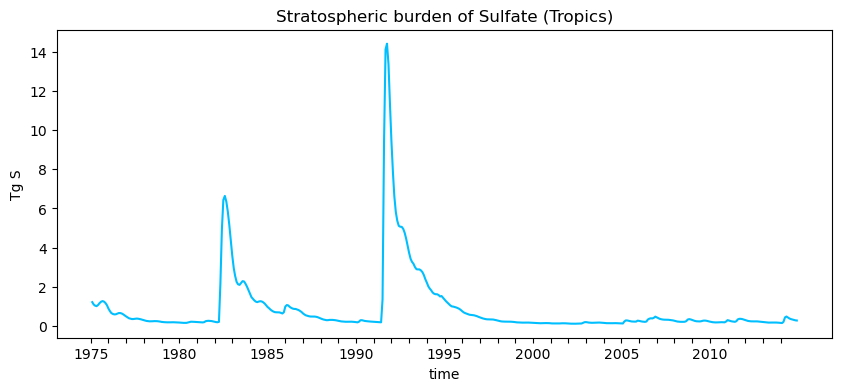

In [25]:
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd_trop = so4_burd.sel(lat=slice(-20, 20))
so4_burd_trop = so4_burd_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden_trop = so4_burd_trop * M_strat_air *10**(-12)
so4_burden_TgS_trop = so4_burden_trop * c

plt.figure(figsize=(10, 4))
so4_burden_TgS_trop.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric burden of Sulfate (Tropics)")

In [ ]:
path_obs = "/nird/projects/NS1004K/elihho/obs_pinatubo/dataset/Observation"

/tmp/ipykernel_3783996/1212671360.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_3783996/1212671360.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)


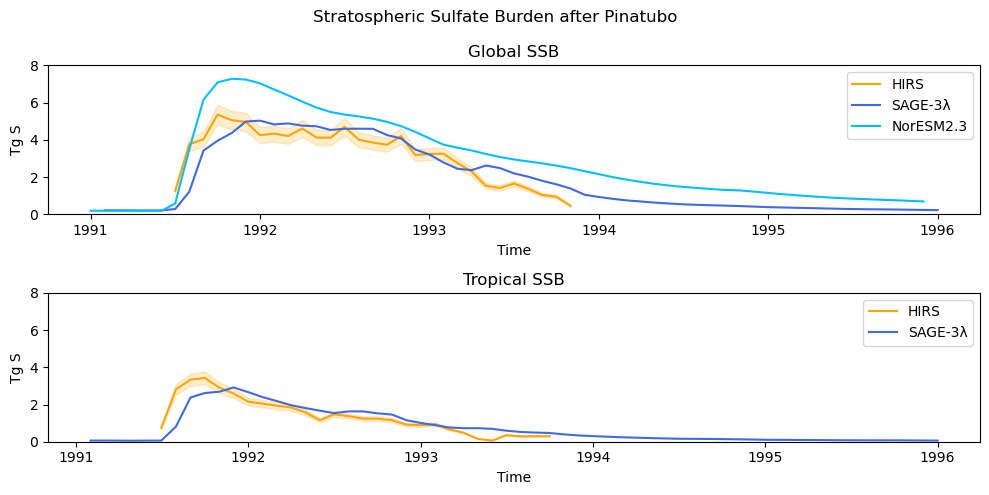

In [ ]:
hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)

start = pd.Timestamp("1991-01-01")
months = [int(c) for c in hirs_sulf_burd.columns]
dates = [start + pd.DateOffset(months=m) for m in months]
hirs_sulf_burd.columns = dates

months_sage = [int(c) for c in sage3l_sulf_burd.columns]
dates_sage = [start + pd.DateOffset(months=m) for m in months_sage]
sage3l_sulf_burd.columns = dates_sage

total = hirs_sulf_burd.loc["Total_burden"].astype(float)
trop  = hirs_sulf_burd.loc["Tropical_burden"].astype(float)
err_total = hirs_sulf_burd.loc["Total_burden_error"].astype(float)
err_trop =  hirs_sulf_burd.loc["Tropical_burden_error"].astype(float)

total_sage = sage3l_sulf_burd.loc["Global"].astype(float)
trop_sage  = sage3l_sulf_burd.loc["Tropical"].astype(float)
obs_time = np.array([t.year + (t.month-1)/12 for t in total_sage.index])
obs_time_hirs = np.array([t.year + (t.month-1)/12 for t in total.index])
time_years = np.array([t.year + (t.month-1)/12 for t in so4_burd_Pinatubo.time.values])

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(obs_time_hirs, total, color="orange", label="HIRS")
ax[0].fill_between(obs_time_hirs, total - err_total, total + err_total,
                 color="orange", alpha=0.2)
ax[0].plot(obs_time, total_sage, color="royalblue", label="SAGE-3λ")
ax[0].plot(time_years, so4_burd_Pinatubo, color = "deepskyblue", label = "NorESM2.3")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Tg S")
ax[0].set_ylim(0,8)
ax[0].set_title("Global SSB")
ax[0].legend()

ax[1].plot(trop.index,  trop,  color="orange", label="HIRS")
ax[1].fill_between(total.index, trop - err_trop, trop + err_trop,
                 color="orange", alpha=0.2)
ax[1].plot(trop_sage.index, trop_sage, color="royalblue", label="SAGE-3λ")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Tg S")
ax[1].set_ylim(0,8)
ax[1].set_title("Tropical SSB")
ax[1].legend()


fig.suptitle("Stratospheric Sulfate Burden after Pinatubo")
plt.tight_layout()
plt.show()
